In [3]:
:opt 3
:dep kolmox = { path = "../src/lib" }
:dep plotly = "0.13"
:dep tracing-subscriber = "0.3"
:dep .

use kolmox::compress::{
    brotli::CompressBrotli,
    zstd::CompressZstd,
    Compressor,
    cache::{Cache, InMemoryCache}
};
use std::time::{Duration, Instant};

fn read_from_file(file_path: &str) -> String {
    std::fs::read_to_string(file_path).expect("Failed to read file")
}

Optimization: 3


Brotli Compression Benchmark
Quality: 3, LG Window Size: 20, Compression Ratio: 1.022238, Time: 43.071124ms
Quality: 3, LG Window Size: 21, Compression Ratio: 0.000209, Time: 36.545858ms
Quality: 3, LG Window Size: 22, Compression Ratio: 0.000209, Time: 34.175465ms
Quality: 4, LG Window Size: 20, Compression Ratio: 0.972502, Time: 70.987336ms
Quality: 4, LG Window Size: 21, Compression Ratio: 0.000027, Time: 41.549207ms
Quality: 4, LG Window Size: 22, Compression Ratio: 0.000027, Time: 52.934115ms
Quality: 5, LG Window Size: 20, Compression Ratio: 1.139808, Time: 96.128255ms
Quality: 5, LG Window Size: 21, Compression Ratio: 0.000060, Time: 65.174519ms
Quality: 5, LG Window Size: 22, Compression Ratio: 0.000060, Time: 78.22175ms
Quality: 6, LG Window Size: 20, Compression Ratio: 1.141955, Time: 116.079942ms
Quality: 6, LG Window Size: 21, Compression Ratio: 0.000060, Time: 84.405617ms
Quality: 6, LG Window Size: 22, Compression Ratio: 0.000060, Time: 87.223277ms
Quality: 7, LG Window S

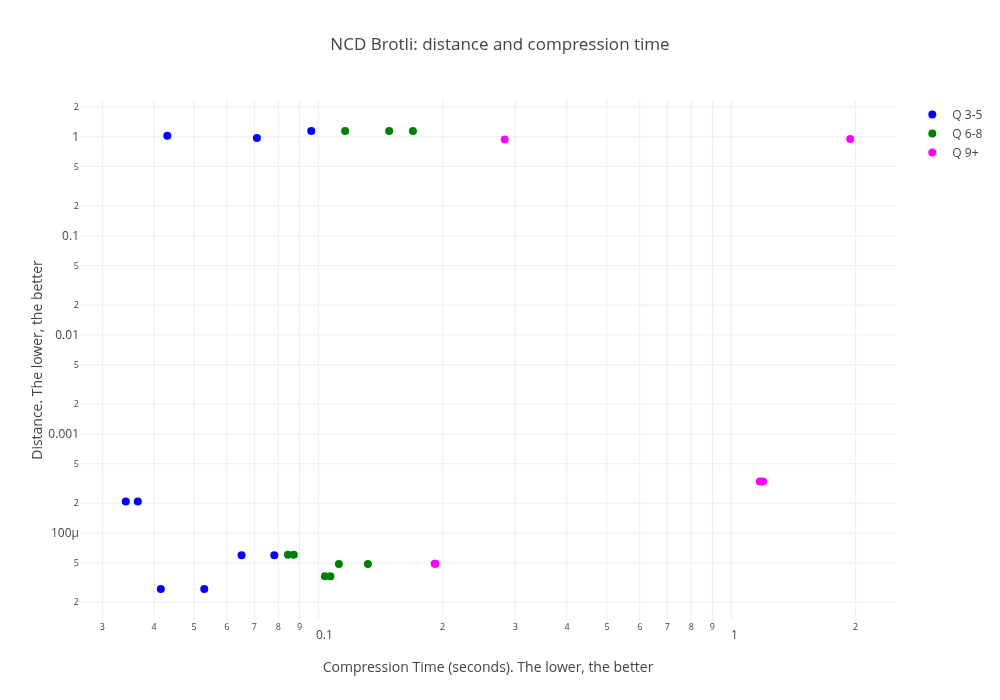

In [4]:
const FILE_PATH: &str =
    "../../dataset/imdb/list/ls541382956/?ref_=tt_urls_2.html";

println!("Brotli Compression Benchmark");
let page_html: String = read_from_file(FILE_PATH);
let mut results: Vec<benchmarks::BenchmarkResult> = Vec::new();

for quality in 3..11 {
    for lg_window_size in 20..=22 {
        let start = Instant::now();
        let compressor = CompressBrotli::<InMemoryCache>::new(quality, lg_window_size);
        let result = compressor.get_distance(&page_html, &page_html);
        let duration = start.elapsed();

        let benchmark_result = benchmarks::BenchmarkResult {
            quality,
            lg_window_size,
            compression_ratio: result,
            duration,
        };

        results.push(benchmark_result.clone());
        println!("Quality: {quality}, LG Window Size: {lg_window_size}, Compression Ratio: {:.6}, Time: {:?}", result, duration);
    }
}

benchmarks::point_series(&results)

In [5]:
let zstd: CompressZstd<InMemoryCache> = CompressZstd::<InMemoryCache>::recommended();

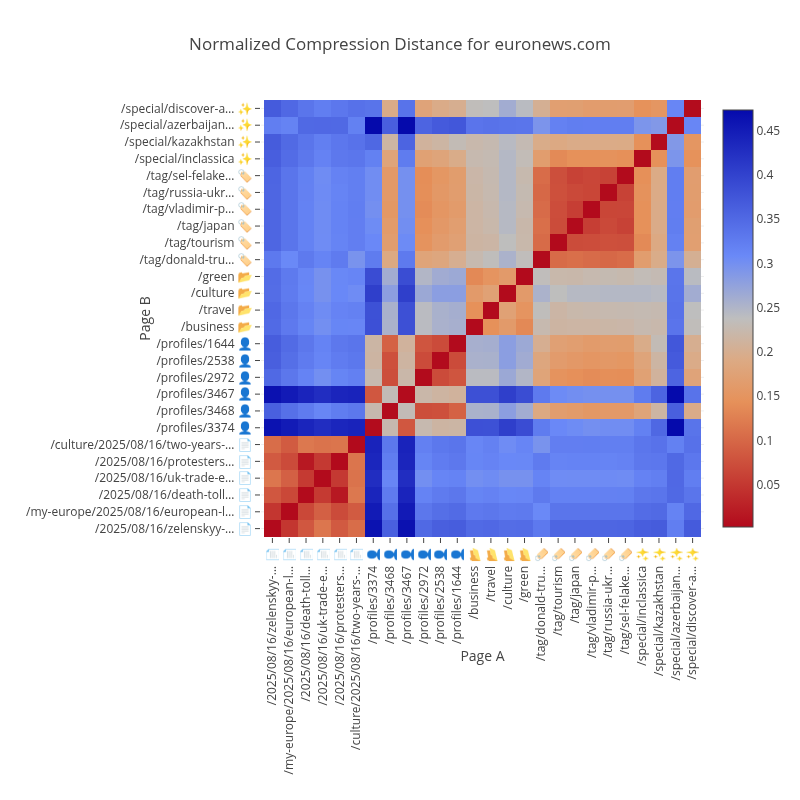

In [6]:
benchmarks::bench_tests::distance_matrix::heatmap(&zstd, "euronews.com")

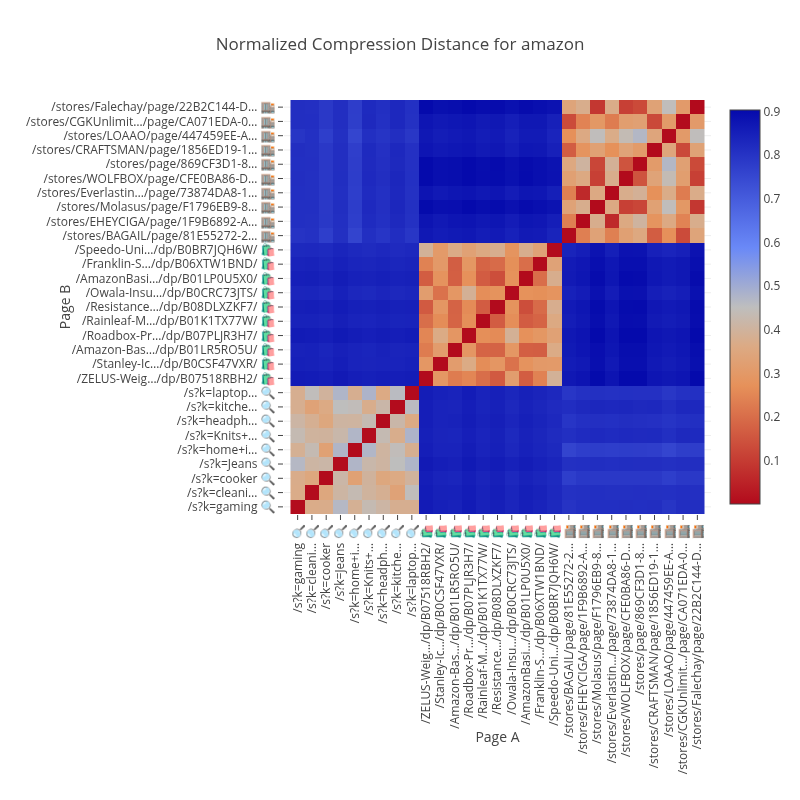

In [7]:
benchmarks::bench_tests::distance_matrix::heatmap(&zstd, "amazon")

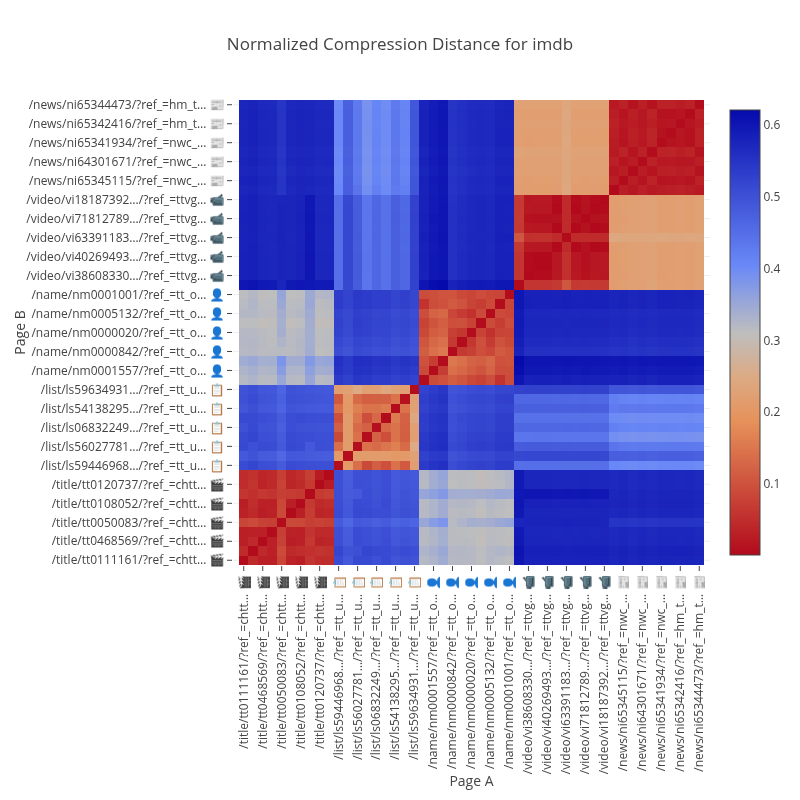

In [8]:
benchmarks::bench_tests::distance_matrix::heatmap(&zstd, "imdb")

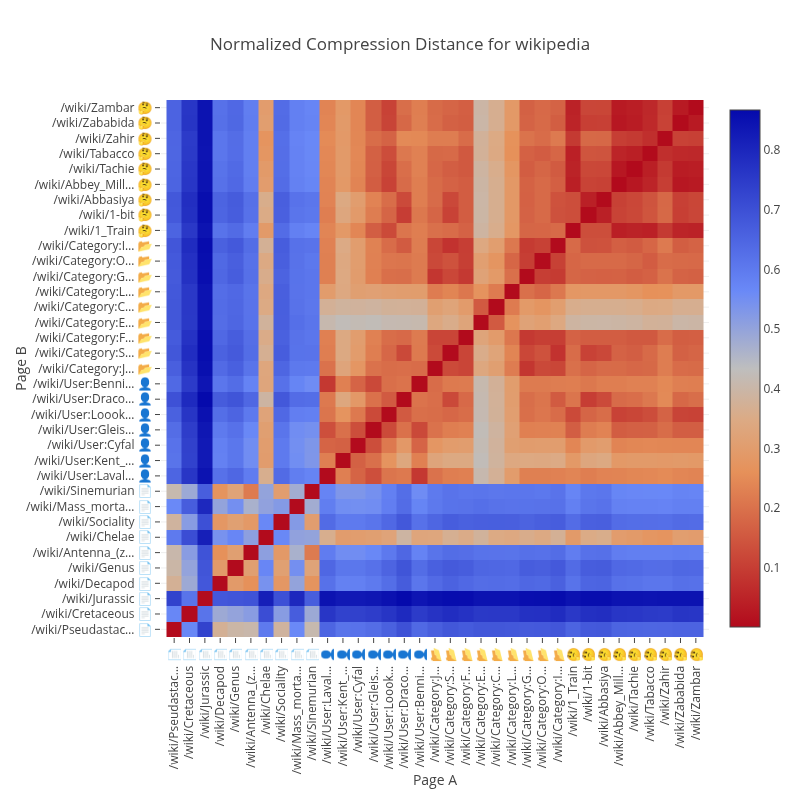

In [9]:
benchmarks::bench_tests::distance_matrix::heatmap(&zstd, "wikipedia")

In [10]:
let wiki_grok: (Vec<String>, Vec<String>, Vec<Vec<f64>>) = benchmarks::bench_tests::wiki_vs_grok::compute_distance_matrix("grokvswiki", &zstd);

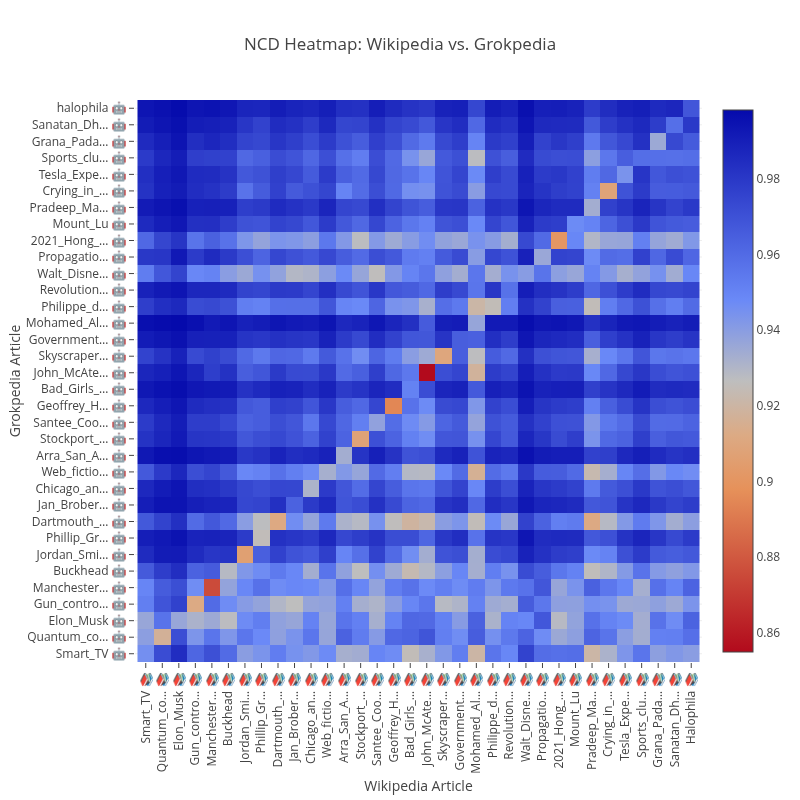

In [11]:
benchmarks::bench_tests::wiki_vs_grok::heatmap(&wiki_grok.0, &wiki_grok.1, &wiki_grok.2)

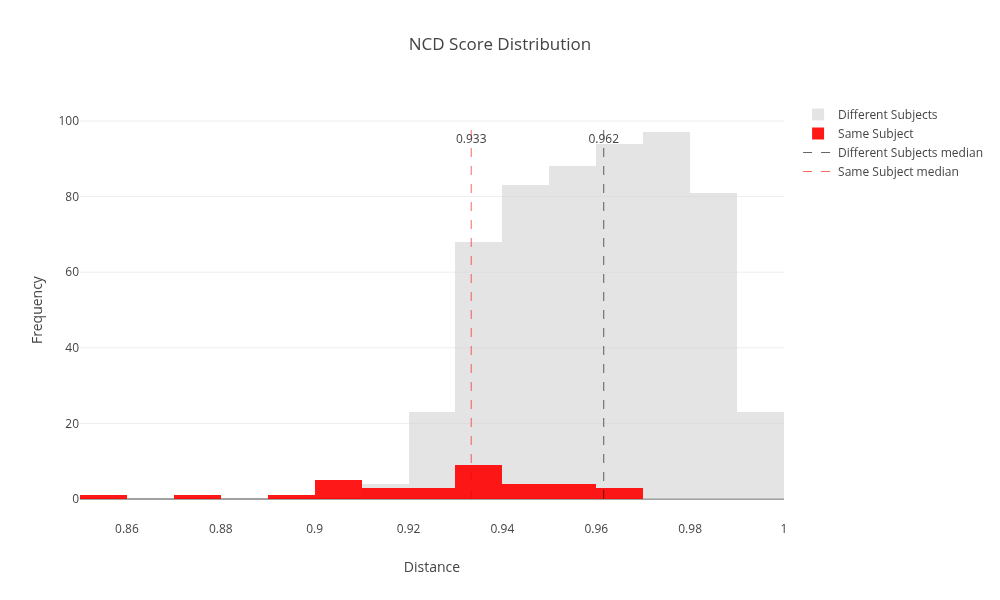

In [12]:
benchmarks::bench_tests::wiki_vs_grok::histogram(&wiki_grok.2)

## BK Tree vs Linear Scan

A brute-force nearest-neighbour search by NCD costs `O(n)` distance computations per query, and each call runs a full compressor pass — the dominant cost in this pipeline.

A BK tree exploits the triangle inequality of the metric: if a node sits at distance `d` from the query and a child sits at distance `d_child` from that node, the child's distance to the query is bounded in `[|d - d_child|, d + d_child]`. Subtrees whose band falls outside the tolerance are pruned without computing their NCD, pushing query cost toward `O(log n)` on well-distributed data.

The benchmark below contrasts `avg_brute_calls` against `avg_tree_calls` per dataset at `tolerance = 0.01`.

In [13]:
let _ = tracing_subscriber::fmt().with_writer(std::io::stdout).try_init();

for ds in ["euronews.com", "amazon", "imdb", "wikipedia"] {
    let compressor = CompressZstd::<InMemoryCache>::recommended();
    benchmarks::bench_tests::bk_tree::bk_tree(compressor, ds, 0.01);
}

2026-05-21T15:50:29.906026Z  INFO benchmarks::bench_tests::bk_tree: BK tree benchmark dataset="euronews.com" pages=26 tolerance=0.01 tolerance_scaled=100
2026-05-21T15:50:29.906039Z  INFO benchmarks::bench_tests::bk_tree: Warming c(x) cache
2026-05-21T15:50:33.593847Z  INFO benchmarks::bench_tests::bk_tree: BK tree built build_time=1.499299287s build_calls=25
2026-05-21T15:50:51.540591Z  INFO benchmarks::bench_tests::bk_tree: BK tree benchmark complete dataset="euronews.com" queries=26 mismatches=0 avg_brute_calls=13 avg_tree_calls=7
2026-05-21T15:50:52.145470Z  INFO benchmarks::bench_tests::bk_tree: BK tree benchmark dataset="amazon" pages=29 tolerance=0.01 tolerance_scaled=100
2026-05-21T15:50:52.145492Z  INFO benchmarks::bench_tests::bk_tree: Warming c(x) cache
2026-05-21T15:50:58.694538Z  INFO benchmarks::bench_tests::bk_tree: BK tree built build_time=3.167383786s build_calls=28
2026-05-21T15:51:38.748657Z  INFO benchmarks::bench_tests::bk_tree: BK tree benchmark complete dataset="

()